In [22]:
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [23]:
df = pd.read_csv('/Users/maria/Desktop/Code/HSE/MACRO/дз_2/data - Лист1.csv')
df

,Year,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
0,1992,75.33,36673.91,15.84,5.75,17671000.0,100.00,203480.54,26573.71,70262.00,4.27,18604.72,-5.30,207.42,60.61,24994401.00,15.45,444.00,66.89,0.0,21.97,8.66,0
1,1993,46.74,36673.91,15.84,4.74,13128900.0,1271.40,203480.54,26573.71,72918.00,4.27,711.00,-9.20,207.42,60.61,22651499.00,12.00,408.00,66.89,0.0,21.97,8.66,0
2,1994,47.12,36673.91,15.84,3.18,10520000.0,659.70,203480.54,2637.00,80441.00,4.27,1216.00,-12.60,35.54,60.61,26181682.00,5.50,415.00,66.89,0.0,21.97,8.66,0
3,1995,43.55,3038.00,15.84,4.19,14902200.0,964.26,203480.54,2806.00,95686.00,4.27,1660.00,-8.20,60.95,24.99,20969975.00,2.50,414.00,66.89,0.0,21.97,8.66,0
4,1996,36.00,4008.00,15.84,4.63,12975100.0,1136.88,203480.54,2781.00,42208.00,4.27,1960.00,0.50,67.30,32.94,21071975.00,1.73,457.00,66.89,0.0,21.97,8.66,0
5,1997,37.44,3560.00,15.84,5.75,13132600.0,1321.91,203480.54,2986.00,59005.00,4.27,2223.00,1.70,75.44,34.16,25079970.00,0.00,521.00,66.89,0.0,21.97,8.66,0
6,1998,34.86,3354.00,15.84,5.63,9335800.0,1160.89,203480.54,4026.00,90091.00,4.27,1965.00,-1.90,78.30,36.70,23402972.00,0.13,526.00,66.89,0.0,21.97,8.66,0
7,1999,40.12,2313.00,15.84,7.15,9616700.0,1437.69,203480.54,2959.00,121177.00,4.27,2001.00,2.70,119.52,43.64,17097980.00,0.08,604.00,66.89,0.0,21.97,8.66,0
8,2000,49.10,3873.00,15.84,8.18,16156800.0,1282.52,72276.00,3998.00,228311.00,4.27,2099.00,9.80,142.13,50.12,26238193.00,0.08,718.00,29.36,0.0,22.92,13.15,0
9,2001,46.95,5496.00,15.84,8.23,15886300.0,2835.00,73611.00,5683.00,207326.00,4.27,2506.00,13.50,146.74,56.07,29366459.00,1.64,815.00,24.46,0.0,23.38,8.37,0


In [24]:
df.columns.tolist()

['Year',
 'Import',
 'Gross National Savings',
 'Government Debt',
 'Natural Gas Production',
 'Iron Ore Production',
 'Inbound Foreign Direct Investment',
 'Natural Population Growth',
 'Government Budget Revenues',
 'Coal Imports',
 'Share of Military Expenditures in the Budget',
 'Foreign Reserves',
 'GDP Growth',
 'Average Annual Exchange Rate to USD',
 'Fuel Exports, % of Merchandise Exports',
 'Coal Exports',
 'Electricity Exports',
 'OIL Production',
 'Oil Prices',
 'Fiscal Rule',
 'Expenditure',
 'Consumer Price Inflation',
 'Politic leader']

In [25]:
df.isna().mean() * 100

Year                                            0.0
Import                                          0.0
Gross National Savings                          0.0
Government Debt                                 0.0
Natural Gas Production                          0.0
Iron Ore Production                             0.0
Inbound Foreign Direct Investment               0.0
Natural Population Growth                       0.0
Government Budget Revenues                      0.0
Coal Imports                                    0.0
Share of Military Expenditures in the Budget    0.0
Foreign Reserves                                0.0
GDP Growth                                      0.0
Average Annual Exchange Rate to USD             0.0
Fuel Exports, % of Merchandise Exports          0.0
Coal Exports                                    0.0
Electricity Exports                             0.0
OIL Production                                  0.0
Oil Prices                                      0.0
Fiscal Rule 

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 23 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Year                                          34 non-null     int64  
 1   Import                                        34 non-null     float64
 2   Gross National Savings                        34 non-null     float64
 3   Government Debt                               34 non-null     float64
 4   Natural Gas Production                        34 non-null     float64
 5   Iron Ore Production                           34 non-null     float64
 6   Inbound Foreign Direct Investment             34 non-null     float64
 7   Natural Population Growth                     34 non-null     float64
 8   Government Budget Revenues                    34 non-null     float64
 9   Coal Imports                                  34 non-null     float

In [27]:
df = df.rename(columns={"Year": "Date"})

## 3.Госдолг


### 5. Выберите зависимую переменную для эконометрического исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [72]:
df["Government Debt"].describe().round(3)

count    34.000
mean     16.184
std       5.083
min       6.680
25%      13.075
50%      15.840
75%      19.822
max      26.360
Name: Government Debt, dtype: float64

Text(0.5, 1.0, 'Dynamics of Government Debt in Kazakhstan')

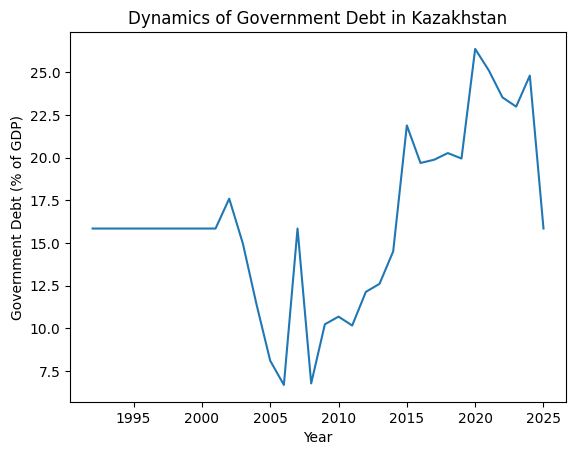

In [75]:
plt.figure()
plt.plot(df["Date"], df["Government Debt"])
plt.xlabel("Year")
plt.ylabel("Government Debt (% of GDP)")
plt.title("Dynamics of Government Debt in Kazakhstan")

### 6. Выберите объясняющую переменную, отвечающую за работу фискального правила. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [58]:
df["Oil Prices"].describe().round(3)

count     34.000
mean      66.891
std       23.623
min       24.460
25%       54.232
50%       66.890
75%       77.818
max      111.570
Name: Oil Prices, dtype: float64

Text(0.5, 1.0, 'Dynamics of Oil Prices in Kazakhstan')

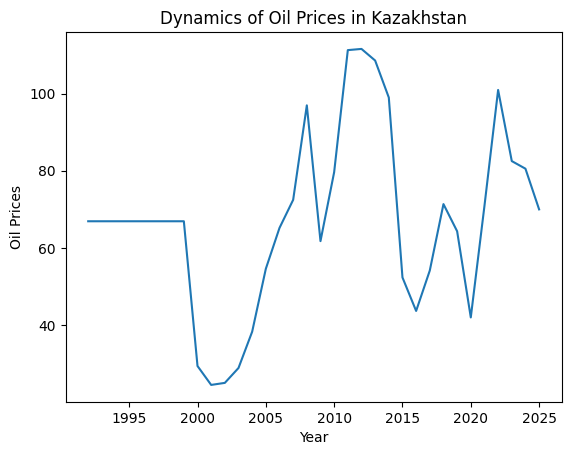

In [59]:
plt.figure()
plt.plot(df["Date"], df["Oil Prices"])
plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title("Dynamics of Oil Prices in Kazakhstan")

### 7. Выберите контрольные переменные для Вашего исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранных переменных, опишите ее. Приведите ссылки на статистические источники.

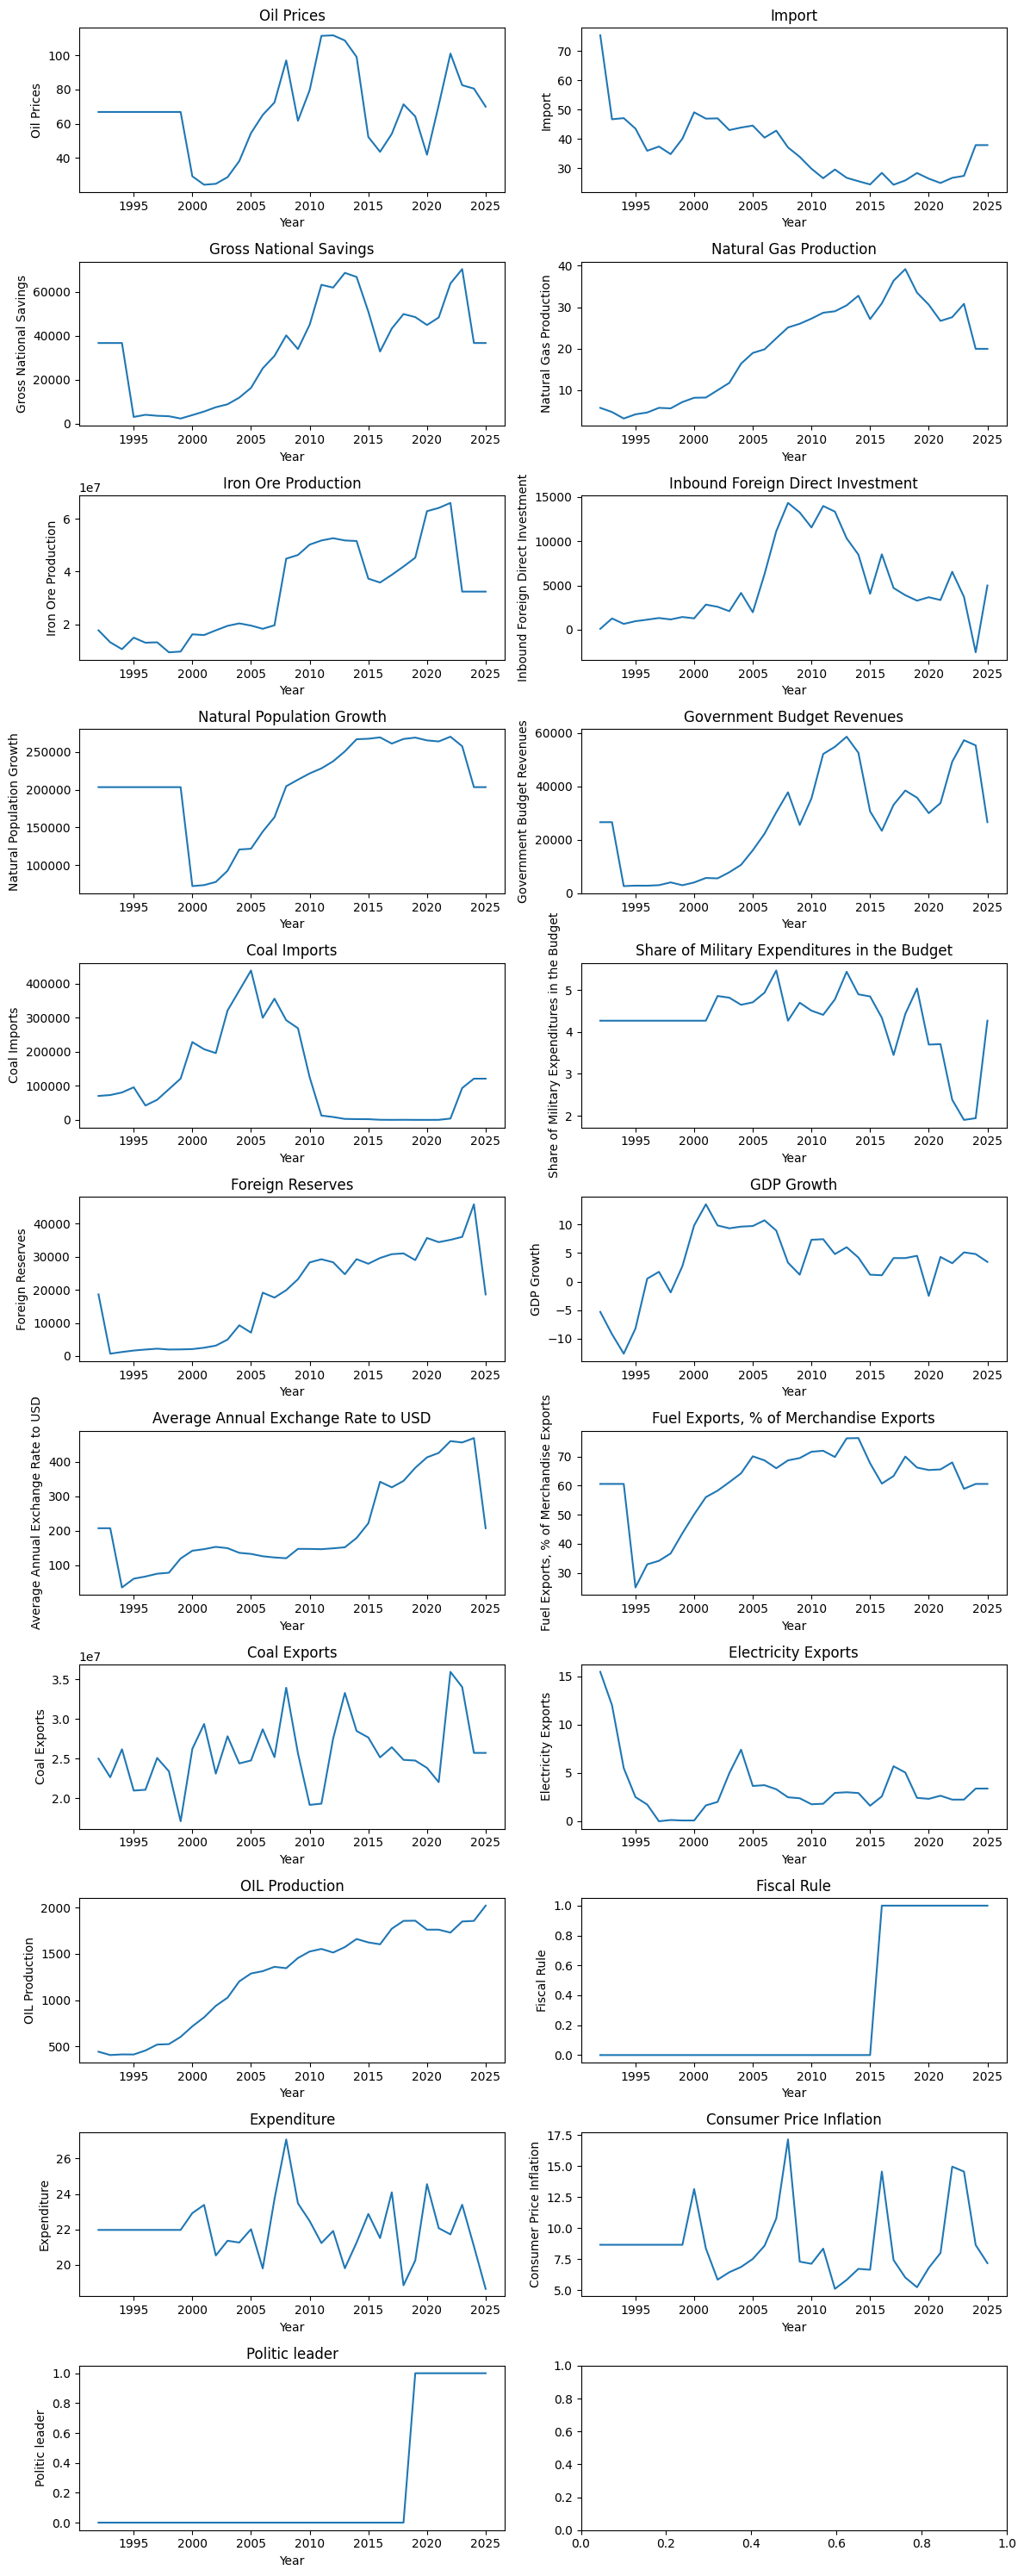

In [76]:
y = df["Government Debt"]

vars_to_plot = [
    'Oil Prices',                 
    'Import',
    'Gross National Savings',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'GDP Growth',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Fiscal Rule',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]

fig, axes = plt.subplots(11, 2, figsize=(12, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    axes[i].plot(df["Date"], df[var])
    axes[i].set_title(var)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel(var)

plt.tight_layout()

### 8. Если Вы используете дамми-переменную в своем исследовании, опишите и обоснуйте.

### 9. Выпишите уравнение спецификации, которое Вы будете оценивать. В таблице опишите все основные описательные статистики выбранных переменных.

In [61]:
df.describe().round(2)

,Date,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,2008.50,36.53,33569.52,16.18,19.97,31936761.76,4994.21,203480.54,26573.71,120972.59,4.27,18604.72,3.43,207.42,60.61,25723621.19,3.38,1257.72,66.89,0.29,21.97,8.66,0.21
std,9.96,10.65,22108.82,5.08,11.16,17705090.54,4545.76,61390.31,18631.01,129956.72,0.82,13623.14,5.89,128.28,12.54,4220621.13,3.11,533.55,23.62,0.46,1.62,2.93,0.41
min,1992.00,24.43,2313.00,6.68,3.18,9335800.00,-2550.49,72276.00,2637.00,21.00,1.90,711.00,-12.60,35.54,24.99,17097980.00,0.00,408.00,24.46,0.00,18.65,5.11,0.00
25%,2000.25,26.96,9553.25,13.08,8.19,16535350.00,1350.86,203480.54,6216.50,3113.50,4.27,2664.75,1.20,127.79,59.35,23510567.50,1.86,742.25,54.23,0.00,21.26,6.82,0.00
50%,2008.50,36.58,36673.91,15.84,21.24,32363100.00,3691.76,203480.54,26573.71,85266.00,4.27,19505.00,4.15,149.35,63.80,25170530.50,2.54,1407.50,66.89,0.00,21.97,8.36,0.00
75%,2016.75,43.42,48426.50,19.82,28.93,45991475.00,8002.58,260375.25,37255.25,204502.50,4.76,29241.25,7.38,299.93,68.72,27631718.00,3.58,1712.07,77.82,1.00,22.77,8.66,0.00
max,2025.00,75.33,70302.00,26.36,39.18,66000000.00,14321.76,270370.00,58577.00,438410.00,5.47,45808.00,13.50,468.96,76.39,35948140.00,15.45,2019.86,111.57,1.00,27.07,17.15,1.00


### 10.  Используя МНК, эмпирически оцените коэффициенты Вашей модели. Результаты оценки представьте в тексте в адекватном и аккуратном виде. Вы обязаны скопировать результаты из используемой программы в Приложение! Без этого работа оценивается как 0. Проинтерпретируйте полученные результаты.

 # Как варик брать не все-все переменные, а с самой большой корреляцыей по модулю

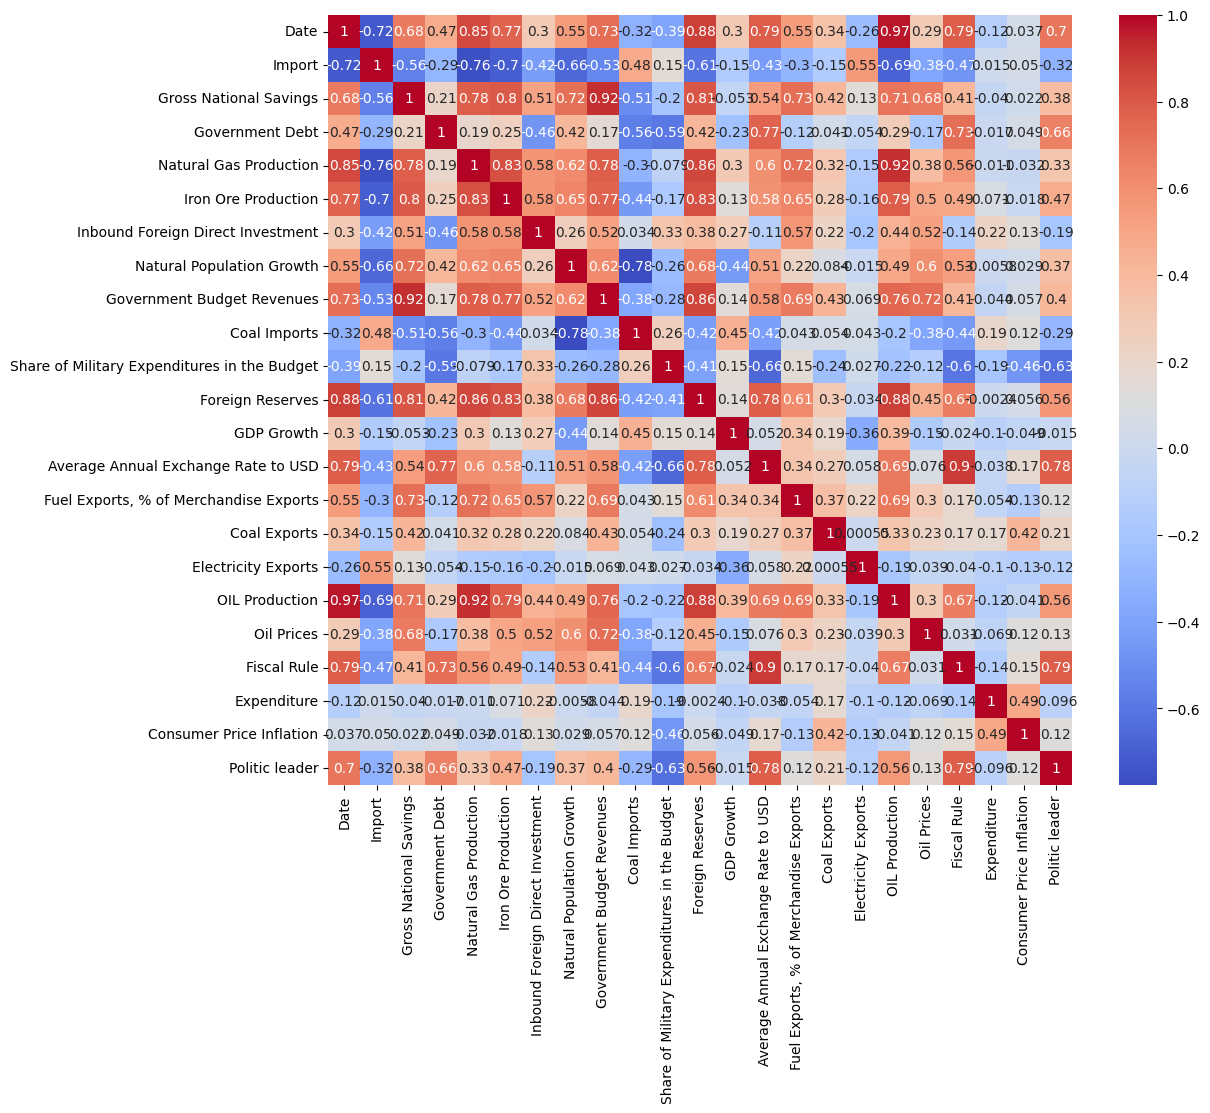

In [62]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)

target = "Government Debt"   # или любой другой столбец

top8 = corr[target].abs().sort_values(ascending=False).iloc[1:9]
top8

In [79]:
y = df["Government Debt"]

X = df[[
    "Import",
    "Gross National Savings",
    "Natural Gas Production",
    "Iron Ore Production",
    "Inbound Foreign Direct Investment",
    "Natural Population Growth",
    "Government Budget Revenues",
    "Coal Imports",
    "Share of Military Expenditures in the Budget",
    "Foreign Reserves",
    "GDP Growth",
    "Average Annual Exchange Rate to USD",
    "Fuel Exports, % of Merchandise Exports",
    "Coal Exports",
    "Electricity Exports",
    "OIL Production",
    "Oil Prices",
    "Fiscal Rule",
    "Expenditure",
    "Consumer Price Inflation",
    "Politic leader"
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Government Debt   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     8.736
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           0.000204
Time:                        00:21:42   Log-Likelihood:                -55.579
No. Observations:                  34   AIC:                             155.2
Df Residuals:                      12   BIC:                             188.7
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                          -13.6346     16.339     -0.834      0.420     -49.235      21.965
Import                                          -0.0278      0.123     -0.226      0.825      -0.295       0.239
Gross National Savings                           0.0004      0.000      2.694      0.020    6.91e-05       0.001
Natural Gas Production                          -0.8458      0.336     -2.520      0.027      -1.577      -0.115
Iron Ore Production                           3.251e-08   9.39e-08      0.346      0.735   -1.72e-07    2.37e-07
Inbound Foreign Direct Investment               -0.0003      0.000     -1.028      0.324      -0.001       0.000
Natural Population Growth                    -1.769e-05   4.43e-05     -0.400      0.697      -0.000    7.88e-05
Government Budget Revenues                      -0.0002      0.000     -0.987      0.343      -0.001       0.000
Coal Imports                                   7.67e-06   1.53e-05      0.501      0.625   -2.57e-05     4.1e-05
Share of Military Expenditures in the Budget     3.8568      1.472      2.620      0.022       0.650       7.064
Foreign Reserves                                 0.0001      0.000      0.802      0.438      -0.000       0.000
GDP Growth                                       0.0022      0.221      0.010      0.992      -0.480       0.484
Average Annual Exchange Rate to USD              0.0653      0.025      2.612      0.023       0.011       0.120
Fuel Exports, % of Merchandise Exports          -0.3102      0.125     -2.475      0.029      -0.583      -0.037
Coal Exports                                  2.589e-08   1.32e-07      0.197      0.847   -2.61e-07    3.13e-07
Electricity Exports                             -0.5598      0.367     -1.527      0.153      -1.358       0.239
OIL Production                                   0.0080      0.006      1.300      0.218      -0.005       0.021
Oil Prices                                       0.0339      0.101      0.335      0.743      -0.187       0.255
Fiscal Rule                                      6.0515      6.460      0.937      0.367      -8.024      20.127
Expenditure                                      1.0868      0.454      2.396      0.034       0.099       2.075
Consumer Price Inflation                        -0.4810      0.295     -1.632      0.129      -1.123       0.161
Politic leader                                 -11.3900      4.861     -2.343      0.037     -21.981      -0.799
==============================================================================
Omnibus:                        3.265   Durbin-Watson:                   2.902
Prob(Omnibus):                  0.195   Jarque-Bera (JB):                2.185
Skew:                

In [80]:
model.params.round(5)

const                                          -13.63457
Import                                          -0.02778
Gross National Savings                           0.00036
Natural Gas Production                          -0.84578
Iron Ore Production                              0.00000
Inbound Foreign Direct Investment               -0.00027
Natural Population Growth                       -0.00002
Government Budget Revenues                      -0.00019
Coal Imports                                     0.00001
Share of Military Expenditures in the Budget     3.85677
Foreign Reserves                                 0.00011
GDP Growth                                       0.00222
Average Annual Exchange Rate to USD              0.06531
Fuel Exports, % of Merchandise Exports          -0.31020
Coal Exports                                     0.00000
Electricity Exports                             -0.55981
OIL Production                                   0.00802
Oil Prices                     

In [81]:
p = model.pvalues

significant = [var for var in p.index if p[var] < 0.10]
nonsignificant = [var for var in p.index if p[var] >= 0.10]

print("Значимые переменные:", significant)
print("Незначимые переменные:", nonsignificant)


Значимые переменные: ['Gross National Savings', 'Natural Gas Production', 'Share of Military Expenditures in the Budget', 'Average Annual Exchange Rate to USD', 'Fuel Exports, % of Merchandise Exports', 'Expenditure', 'Politic leader']
Незначимые переменные: ['const', 'Import', 'Iron Ore Production', 'Inbound Foreign Direct Investment', 'Natural Population Growth', 'Government Budget Revenues', 'Coal Imports', 'Foreign Reserves', 'GDP Growth', 'Coal Exports', 'Electricity Exports', 'OIL Production', 'Oil Prices', 'Fiscal Rule', 'Consumer Price Inflation']


также, построим 95% доверительные интервалы для всех коэффициентов:

In [82]:
conf = model.conf_int(alpha=0.05)

significant_ci = []
nonsignificant_ci = []

for var in conf.index:
    low, high = conf.loc[var]
    if low > 0 or high < 0:      # интервал не содержит ноль
        significant_ci.append(var)
    else:
        nonsignificant_ci.append(var)

print("Значимые по доверительным интервалам:", significant_ci)
print("Незначимые по доверительным интервалам:", nonsignificant_ci)

Значимые по доверительным интервалам: ['Gross National Savings', 'Natural Gas Production', 'Share of Military Expenditures in the Budget', 'Average Annual Exchange Rate to USD', 'Fuel Exports, % of Merchandise Exports', 'Expenditure', 'Politic leader']
Незначимые по доверительным интервалам: ['const', 'Import', 'Iron Ore Production', 'Inbound Foreign Direct Investment', 'Natural Population Growth', 'Government Budget Revenues', 'Coal Imports', 'Foreign Reserves', 'GDP Growth', 'Coal Exports', 'Electricity Exports', 'OIL Production', 'Oil Prices', 'Fiscal Rule', 'Consumer Price Inflation']


### 11.  Проведите проверку результатов на устойчивость. Метод Вы выбираете сами. Устойчивы ли Ваши результаты?

#### 1 способ: Робастные стандартные ошибки (HC3)

In [83]:
model_robust = model.get_robustcov_results(cov_type="HC3")

p = model_robust.pvalues
names = model_robust.model.exog_names

significant = [names[i] for i in range(len(p)) if p[i] < 0.10]
nonsignificant = [names[i] for i in range(len(p)) if p[i] >= 0.10]

print("Значимые (robust):", significant)
print("Незначимые (robust):", nonsignificant)

Значимые (robust): []
Незначимые (robust): ['const', 'Import', 'Gross National Savings', 'Natural Gas Production', 'Iron Ore Production', 'Inbound Foreign Direct Investment', 'Natural Population Growth', 'Government Budget Revenues', 'Coal Imports', 'Share of Military Expenditures in the Budget', 'Foreign Reserves', 'GDP Growth', 'Average Annual Exchange Rate to USD', 'Fuel Exports, % of Merchandise Exports', 'Coal Exports', 'Electricity Exports', 'OIL Production', 'Oil Prices', 'Fiscal Rule', 'Expenditure', 'Consumer Price Inflation', 'Politic leader']


#### 2 способ: Мультиколлинеарность (VIF)

In [84]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Variable,VIF
0,const,2080.923935
1,Import,12.900189
2,Gross National Savings,66.486947
3,Natural Gas Production,106.153955
4,Iron Ore Production,20.925709
5,Inbound Foreign Direct Investment,10.673569
6,Natural Population Growth,55.914570
7,Government Budget Revenues,95.977148
8,Coal Imports,29.931206
9,Share of Military Expenditures in the Budget,10.953230


#### 3 способ: оценка модели на части признаков. (Leave-one-out robustness check)

Мы проверяем, насколько чувствительны результаты модели к выбору набора регрессоров. Для этого по очереди исключаем из модели каждую объясняющую переменную, заново оцениваем регрессию и смотрим, как изменяется коэффициент при ключевой переменной FiscalRule. Если коэффициент остаётся примерно таким же, значит модель устойчива к спецификации; если изменяется резко, значит зависимость чувствительна к исключению этой переменной.

Этот метод широко используется как тест устойчивости результатов (robustness to model specification).

In [85]:
y = df["GDP Growth"]

control_vars = [
    'Import',
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]

results = []

for var in control_vars:
    vars_subset = [v for v in control_vars if v != var]
    model = sm.OLS(y, sm.add_constant(df[vars_subset + ["Oil Prices"]])).fit()
    coef = model.params.get("Oil Prices", None)
    results.append([var, coef])

pd.DataFrame(results, columns=["Removed variable", "OilPrices coefficient"])

,Removed variable,OilPrices coefficient
0,Import,0.165735
1,Gross National Savings,0.165379
2,Government Debt,0.147213
3,Natural Gas Production,0.178201
4,Iron Ore Production,0.142880
5,Inbound Foreign Direct Investment,0.171483
6,Natural Population Growth,-0.097154
7,Government Budget Revenues,0.106581
8,Coal Imports,0.155317
9,Share of Military Expenditures in the Budget,0.090085


### 12.  Постройте прогноз, используя Вашу оцененную модель. Результаты представьте на графике. Опишите его и проинтерпретируйте.

прогноз по 3-летнему скользящему среднему (MA-3) и подстановка результата OLS-модель.

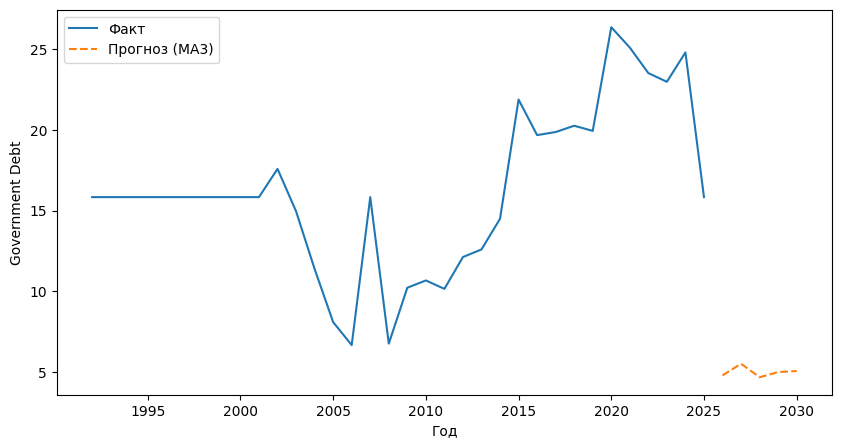

In [86]:
X_vars = [
    'Import',
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Oil Prices',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader',
    'Fiscal Rule'
]

future_years = [2026, 2027, 2028, 2029, 2030]

X_extended = df[X_vars].copy()

for year in future_years:
    ma3 = X_extended.tail(3).mean()
    X_extended.loc[year] = ma3

X_future = X_extended.loc[future_years].copy()
X_future["const"] = 1
X_future = X_future[model.model.exog_names]

forecast_ma = model.predict(X_future)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Government Debt"], label="Факт")
plt.plot(forecast_ma.index, forecast_ma.values, label="Прогноз (MA3)", linestyle="--")
plt.xlabel("Год")
plt.ylabel("Government Debt")
plt.legend()
plt.show()